# Kimi K3 — inference roofline

Where a decode step and a prefill chunk actually spend their time.

Two numbers per operation; you wait for the larger:

`t_compute = FLOPs / peak_flops(precision)`  ·  `t_memory = bytes / bandwidth`

**Steps 1-8 are the argument.** The appendix at the end holds the derivations and
side quests — why intensity lands where it does, the roofline chart, and how the
numbers move with context, batch and chunk size.

Plumbing in `roofline.py`; model shapes in `models.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from models import K3Config, build
from roofline import (GPU, balance_table, build_ops, by_layer, explain_gemm, footprint,
                      machine_intensity, op_table, summarise, vs_ridge,
                      build_ops_prefill, experts_touched,
                      op_prefill_sweep, summary,
                      Fabric, tensor_parallel, allreduce_time,
                      hybrid_parallel, busiest_gpu_experts,
                      expert_load_imbalance)
from flops import params_by_hand

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)

COMPUTE, MEMORY = "#2a78d6", "#eb6834"
cfg = K3Config()
model = build(cfg)

## 1. Hand-derived FLOPs vs the loaded model

Same cross-check as the first notebook, so the numbers everything below rests on
are known good. `params_by_hand` uses only config integers; `model.breakdown()`
walks the real module tree.

In [2]:
hand, real = params_by_hand(cfg), model.breakdown()
check = pd.DataFrame({"by hand": hand, "from model": real})
check["diff"] = check["by hand"] - check["from model"]
check.loc["TOTAL"] = [sum(hand.values()), model.total_params(), 0]

print(f"2N by hand     {2 * sum(v for k, v in hand.items() if k != 'Embedding') / 1e9:8.3f} GFLOP/token")
print(f"2N from model  {2 * model.active_params() / 1e9:8.3f} GFLOP/token")
print(f"all buckets agree: {(check['diff'] == 0).all()}")
check

2N by hand     5556.616 GFLOP/token


2N from model   208.375 GFLOP/token
all buckets agree: True


,by hand,from model,diff
KDA,30618086496,30618086496,0
Gated MLA,5572706304,5572706304,0
MoE routed,2722740830208,2722740830208,0
MoE shared,12155092992,12155092992,0
MoE down/up,4726980608,4726980608,0
MoE router,591284736,591284736,0
Dense FFN,726663168,726663168,0
Embedding,1174405120,1174405120,0
Output head,1174405120,1174405120,0
Other,2007040,2007040,0


## 2. Does it even fit?

Before timing anything: the paper serves MoE expert weights in **MXFP4** with
MXFP8 activations, and leaves everything else (attention projections, latent
projections, shared experts, routers) in higher precision (§4.1.4).

That split matters enormously, because the experts are 98% of the parameters.
MXFP4 is 4-bit elements plus one FP8 scale per block of 32, so 4.25 bits each.

In [3]:
fp = footprint(cfg)
print(fp.round(2).to_string())
print(f"\nquantising experts saves {fp['weights all BF16 (GB)'] - fp['weights MXFP4+BF16 (GB)']:,.0f} GB")
print(f"still needs {np.ceil(fp['GPUs to hold weights']):.0f} GPUs just to hold the weights,")
print("so everything below is per-GPU time for a model that is really sharded.")

expert params (B)          2722.74
other params (B)             56.74
weights MXFP4+BF16 (GB)    1559.94
weights all BF16 (GB)      5558.96
one GPU HBM (GB)            309.24
GPUs to hold weights          5.04

quantising experts saves 3,999 GB
still needs 6 GPUs just to hold the weights,
so everything below is per-GPU time for a model that is really sharded.


## 3. Per-operation: work, traffic, and both bounds

One row per kernel an inference engine actually launches, with everything needed
to say what limits it.

**Arithmetic intensity** is the ratio that decides it:

$$I = \frac{\text{FLOPs for the op}}{\text{bytes shuttled from DRAM}} \qquad [\text{FLOP}/\text{byte}]$$

Compare it against the **machine balance**, `peak FLOP/s ÷ bandwidth`, which is
how much arithmetic the GPU can do per byte it can fetch. Above the balance the
op is compute bound; below it, memory bound. Equivalently just take the larger of
the two times — same answer.

The two bounds, spelled out:

| column | formula | what it means |
|---|---|---|
| `COMPUTE <prec> (us)` | `FLOPs / peak_flops(prec)` | how long the math alone would take |
| `MEMORY (us)` | `bytes / bandwidth` | how long the DRAM traffic alone would take |
| `limited by` | argmax of the two | what you actually wait for |

Three precisions are shown for the compute bound so you can see what quantising
further would buy. **Bytes are held fixed across the three** — this asks "if the
arithmetic ran faster, would it help?", not "what if we requantised the weights",
which would change the traffic too.

Three ops are not plain GEMMs:

- **`moe.experts`** — bytes scale with the number of *distinct* experts the batch
  wakes, FLOPs with `k=16`. One token wakes 16 of 896; a big batch wakes nearly all.
- **`mla.attn`** — no weights. Streams the whole KV cache, so bytes grow with context.
- **`kda.recurrence`** — no weights. Fixed-size state, so cost is flat in context.

### The hardware numbers

`GPU()` is the **GB300 NVL72 bin**, per Blackwell Ultra GPU, all **dense** (no
2:4 sparsity). From NVIDIA's own pages:

| | value | note |
|---|---|---|
| HBM3e | 288 GB | per GPU, stated directly |
| bandwidth | 8 TB/s | per GPU (rack 576 TB/s ÷ 72) |
| NVFP4 | 15 PFLOP/s | dense; sparse is 20, **not** 30 |
| FP8 | 5 PFLOP/s | dense |
| BF16 | 2.5 PFLOP/s | derived: rack 360 PF sparse ÷ 2 ÷ 72 |

Two traps worth knowing. **Most published tensor-core figures are sparse** — the
rack pages say so in a footnote — so halving is usually right, *except* for FP4 on
Blackwell Ultra, where dense|sparse is 15|20 rather than 15|30. Halving the sparse
20 gives 10 PF, which is B200's dense rate, not B300's.

And **Blackwell Ultra only raised FP4.** NVFP4 dense went 10 → 15 PF/GPU, while
FP8, BF16 and TF32 stayed exactly at B200 rates (INT8 and FP64 were cut ~30x).
So the gap between the compute columns below is narrower than the "each precision
doubles" rule of thumb suggests: bf16 → fp8 is 2x, but fp8 → mxfp4 is 3x.

`hgx_b300()` gives the air-cooled bin (~10% lower) if you want to compare.

In [4]:
BATCH, SEQ = 1, 131_072      # decode: one token, this much cache behind it
CHUNK, PRIOR = 4096, 0       # prefill: one chunk this big, this much cached
hw = GPU()
ops = build_ops(cfg, batch=BATCH, seq=SEQ, hw=hw)
pre = build_ops_prefill(cfg, chunk=CHUNK, prior=PRIOR, hw=hw)

print(f"{hw.name}")
print(f"  bandwidth {hw.bandwidth / 1e12:.1f} TB/s   "
      f"peak {', '.join(f'{k} {v / 1e15:.1f} PFLOP/s' for k, v in hw.peak.items())}")
print("\nmachine balance -- FLOP/byte needed to keep the tensor cores fed:")
print(balance_table(hw).round(0).to_string())
print(f"\nbatch {BATCH}, context {SEQ:,}\n")

op_table(ops, hw).round(2)

GB300 NVL72 (per B300 GPU)
  bandwidth 8.0 TB/s   peak bf16 2.5 PFLOP/s, fp8 5.0 PFLOP/s, mxfp4 15.0 PFLOP/s

machine balance -- FLOP/byte needed to keep the tensor cores fed:
bf16 (FLOP/byte)      312.0
fp8 (FLOP/byte)       625.0
mxfp4 (FLOP/byte)    1875.0

batch 1, context 131,072



,group,GFLOP,GB from DRAM,intensity (FLOP/byte),COMPUTE bf16 (us),COMPUTE fp8 (us),COMPUTE mxfp4 (us),MEMORY (us),limited by
op,,,,,,,,,
lm_head,Head,2.35,2.35,1.00,0.94,0.47,0.16,293.64,memory
kda.qkv_proj,KDA,36.47,36.47,1.00,14.59,7.29,2.43,4558.92,memory
kda.gate,KDA,12.16,12.16,1.00,4.86,2.43,0.81,1519.72,memory
kda.out,KDA,12.16,12.16,1.00,4.86,2.43,0.81,1519.72,memory
kda.recurrence,KDA,0.65,0.43,1.50,0.26,0.13,0.04,54.26,memory
kda.alpha_up,KDA,0.22,0.22,0.99,0.09,0.04,0.01,27.35,memory
kda.alpha,KDA,0.13,0.13,0.99,0.05,0.03,0.01,15.95,memory
kda.beta,KDA,0.09,0.10,0.99,0.04,0.02,0.01,12.00,memory
mla.out,MLA,4.23,4.23,1.00,1.69,0.85,0.28,528.60,memory


## 4. Every operation, one layer, across prefill lengths

The op breakdown again, but each row is what **one** layer of that type does, and
the columns sweep prefill chunk length. `decode` is the one-token case for
reference.

`compute-bound at` is the smallest chunk where that operation stops waiting on
memory — the practical question when you are sizing chunks.

In [5]:
print("microseconds per ONE layer\n")
op_prefill_sweep(cfg, hw=hw).round(2)

microseconds per ONE layer



,group,layers,decode,C=512,C=1024,C=2048,C=4096,C=8192,C=16384,compute-bound at
op,,,,,,,,,,
lm_head,Head,1,293.64,481.04,962.07,1924.15,3848.29,7696.58,15393.16,C>=512
kda.qkv_proj,KDA,69,66.07,108.23,216.47,432.93,865.87,1731.73,3463.46,C>=512
kda.gate,KDA,69,22.02,36.08,72.16,144.31,288.62,577.24,1154.49,C>=512
kda.out,KDA,69,22.02,36.08,72.16,144.31,288.62,577.24,1154.49,C>=512
kda.recurrence,KDA,69,0.79,2.36,3.93,7.73,15.46,30.92,61.85,C>=2048
kda.alpha_up,KDA,69,0.40,1.98,3.57,6.75,13.11,25.82,51.25,never
kda.alpha,KDA,69,0.23,1.16,2.10,3.96,7.70,15.17,30.11,never
kda.beta,KDA,69,0.17,1.10,2.03,3.89,7.61,15.05,29.93,never
mla.attn (vs cache),MLA,24,18.87,3.23,12.90,51.56,206.21,824.73,3298.74,C>=512


In [6]:
print("GFLOP per ONE layer\n")
op_prefill_sweep(cfg, hw=hw, metric="flops").round(2)

GFLOP per ONE layer



,group,layers,decode,C=512,C=1024,C=2048,C=4096,C=8192,C=16384,compute-bound at
op,,,,,,,,,,
lm_head,Head,1,2.35,1202.59,2405.18,4810.36,9620.73,19241.45,38482.91,C>=512
kda.qkv_proj,KDA,69,0.53,270.58,541.17,1082.33,2164.66,4329.33,8658.65,C>=512
kda.gate,KDA,69,0.18,90.19,180.39,360.78,721.55,1443.11,2886.22,C>=512
kda.out,KDA,69,0.18,90.19,180.39,360.78,721.55,1443.11,2886.22,C>=512
kda.recurrence,KDA,69,0.01,4.83,9.66,19.33,38.65,77.31,154.62,C>=2048
kda.alpha_up,KDA,69,0.00,1.61,3.22,6.44,12.88,25.77,51.54,never
kda.alpha,KDA,69,0.00,0.94,1.88,3.76,7.52,15.03,30.06,never
kda.beta,KDA,69,0.00,0.70,1.41,2.82,5.64,11.27,22.55,never
mla.attn (vs cache),MLA,24,8.05,8.07,32.24,128.91,515.52,2061.84,8246.84,C>=512


In [7]:
print("GB from DRAM per ONE layer\n")
op_prefill_sweep(cfg, hw=hw, metric="bytes").round(3)

GB from DRAM per ONE layer



,group,layers,decode,C=512,C=1024,C=2048,C=4096,C=8192,C=16384,compute-bound at
op,,,,,,,,,,
lm_head,Head,1,2.349,2.524,2.699,3.049,3.750,5.151,7.952,C>=512
kda.qkv_proj,KDA,69,0.529,0.574,0.619,0.709,0.889,1.250,1.971,C>=512
kda.gate,KDA,69,0.176,0.196,0.216,0.256,0.336,0.495,0.814,C>=512
kda.out,KDA,69,0.176,0.196,0.216,0.256,0.336,0.495,0.814,C>=512
kda.alpha_up,KDA,69,0.003,0.016,0.029,0.054,0.105,0.207,0.410,never
kda.recurrence,KDA,69,0.006,0.019,0.031,0.057,0.107,0.208,0.409,C>=2048
kda.alpha,KDA,69,0.002,0.009,0.017,0.032,0.062,0.121,0.241,never
kda.beta,KDA,69,0.001,0.009,0.016,0.031,0.061,0.120,0.239,never
mla.out,MLA,24,0.176,0.196,0.216,0.256,0.336,0.495,0.814,C>=512


### Reading it

**Most rows are linear in chunk length.** `kda.qkv_proj` goes 108 → 3463 us as
`C` goes 512 → 16384, a clean 32x for 32x the tokens. Those ops became compute
bound at the smallest chunk tested, so time just tracks work.

**`moe.experts` is the row that does not.** 1978 us at `C=512`, 2385 us at
`C=16384` — 32x the tokens for 1.2x the time. Look at the GB table and the reason
is plain: 16.4 GB per layer at `C=512`, 16.6 GB at `C=16384`. The chunk barely
changes the bytes, because even 512 tokens already wake essentially all 896
experts, and the whole bank has to be read either way.

So its `compute-bound at` reads **never** across the whole sweep. It is the one
operation you cannot fix with a bigger chunk, and by `C=512` it is already ~2/3
of the per-layer time in a MoE layer.

**Three small KDA ops also read `never`** — `alpha`, `alpha_up`, `beta`. Different
reason: they are tiny low-rank projections whose activation traffic is comparable
to their weights, so their intensity sits near 1 no matter how many tokens flow
through. They cost almost nothing, so it does not matter.

**`mla.attn` is the only row that gets *worse* per token with length**, going
quadratic: 3.2 us at `C=512` up to 3299 us at `C=16384`. At short chunks it is
free; by 16K it rivals `kda.qkv_proj`. That is the term chunked prefill exists to
bound.

## 5. Aggregated by layer type

The same run rolled up. Layer types down the side, the two regimes across the
top, all times in **microseconds**.

`us/token` divides each regime's total by the tokens it produced — 1 for decode,
`CHUNK` for prefill — which is the only fair way to compare them.

In [8]:
summary(ops, pre, CHUNK).round(2)

DECODE (1 token)                                     PREFILL (4,096 tokens)                                              
      layers            TFLOP      GB        us  us/token   bound                  TFLOP       GB         us us/token            bound
group                                                                                                                                 
KDA       69             0.06   61.66   7707.92   7707.92  memory                 253.40   130.73  102602.24    25.05          compute
MLA       24             0.20   14.17   1771.10   1771.10  memory                  55.55    25.46   22219.93     5.42          compute
MoE       92             0.13   60.80   7600.56   7600.56  memory                 541.44  1600.16  247709.26    60.48  mixed (77% mem)
Head       1             0.00    2.35    293.64    293.64  memory                   9.62     3.75    3848.29     0.94          compute
TOTAL    186             0.40  138.99  17373.23  17373.23  memory                 860.01  1760.10  376379.72    91.89  mixed (51% mem)

**Decode is memory bound everywhere.** 0.40 TFLOP against 139 GB moved: the
GPU could do that arithmetic in 160 us and spends 17,373 us waiting on weights.

**Prefill flips almost everything** — 91.89 us/token against decode's 17,373,
about 190x, by doing 4096 tokens of work per weight read.

**The ordering inverts.** KDA is the largest decode cost (7,708 us) despite MoE
holding 98% of the parameters, because only 16 of 896 experts wake while all 69
KDA layers stream a full 7168x12288 projection. In prefill MoE takes two thirds
of the time (247,709 us) because 4096 independently-routed tokens wake all 896 —
and it is the only row still memory bound, at 1,600 GB for a single chunk.

## 6. Tensor parallel: runtime vs GPU count

The model needs ~6 GPUs just to hold its weights, so the single-GPU numbers above
are a fiction. What does the critical path look like when it is actually sharded?

**Megatron-style tensor parallelism.** Inside each block the first matmul is
column-parallel (no communication) and the second is row-parallel, which leaves
every GPU holding a partial sum. One all-reduce fixes it — once after attention,
once after the FFN, so `2 x 93 = 186` collectives per step.

Both FLOPs and bytes shard by `n`, so they shrink together and no operation
changes which resource binds it. The term that does **not** shrink is the
collective:

$$t_{\text{allreduce}} = \underbrace{\ell}_{\text{fixed floor}} + \underbrace{\frac{2(n-1)}{n}\cdot\frac{S}{B}}_{\text{ring bandwidth}}$$

`S` is the activation payload, `batch x 7168 x 2 B`. That is the whole story,
because `S` differs by four orders of magnitude between the two regimes:

| | payload per collective |
|---|---|
| decode (1 token) | **14 KB** — the fixed floor `l` dominates |
| prefill (4096 tokens) | **58.7 MB** — bandwidth dominates |

Fabric assumptions are in `Fabric()`: 900 GB/s unidirectional per GPU (NVLink 5
is 1.8 TB/s bidirectional) and a **5 us** small-message floor. That latency is an
estimate, not a vendor figure — small-message NCCL all-reduce typically lands in
the 3-10 us range, and at batch 1 it sets the answer, so it is swept below.

In [9]:
fab = Fabric()
GPUS = [1, 2, 4, 8, 16, 32, 64, 72]
weights_gb = footprint(cfg, hw)["weights MXFP4+BF16 (GB)"]

tp_dec = tensor_parallel(ops, cfg, GPUS, BATCH, hw, fab, weights_gb)
tp_pre = tensor_parallel(pre, cfg, GPUS, CHUNK, hw, fab, weights_gb)

print(f"{fab.name}: {fab.bw_per_gpu / 1e9:.0f} GB/s per GPU, stack={fab.stack!r}")
print("  all-reduce floor: " + ", ".join(f"{n}gpu {fab.latency_at(n) * 1e6:.1f}us" for n in [8, 32, 72]))
print(f"{2 * cfg.n_layers} collectives/step   "
      f"decode payload {BATCH * cfg.d_model * 2 / 1e3:.1f} KB   "
      f"prefill payload {CHUNK * cfg.d_model * 2 / 1e6:.1f} MB")
print(f"weights {weights_gb:,.0f} GB -> need >= {int(np.ceil(weights_gb / (hw.hbm_bytes / 1e9)))} GPUs\n")
print("DECODE\n" + tp_dec.round(2).to_string())
print("\nPREFILL\n" + tp_pre.round(2).to_string())

NVLink 5 (in-rack): 900 GB/s per GPU, stack='modern'
  all-reduce floor: 8gpu 4.0us, 32gpu 8.0us, 72gpu 13.0us
186 collectives/step   decode payload 14.3 KB   prefill payload 58.7 MB
weights 1,560 GB -> need >= 6 GPUs

DECODE
      memory us  compute us  nvlink us  total us   GB/GPU   fits  speedup  comm share
GPUs                                                                                 
1      17373.23         0.0       0.00  17373.23  1559.94  False     1.00        0.00
2       8686.61         0.0     467.96   9154.58   779.97  False     1.90        0.05
4       4343.31         0.0     562.44   4905.75   389.98  False     3.54        0.11
8       2171.65         0.0     749.18   2920.84   194.99   True     5.95        0.26
16      1085.83         0.0    1028.56   2114.38    97.50   True     8.22        0.49
32       542.91         0.0    1493.74   2036.65    48.75   True     8.53        0.73
64       271.46         0.0    2237.83   2509.29    24.37   True     6.92        0.89


### What the stack says

**Decode: NVLink time is flat, and it wins.** 936 us at every GPU count, because
a 14 KB payload never touches bandwidth — you are paying `186 x 5 us` of fixed
collective floor, and sharding cannot divide a latency. Meanwhile the memory term
halves each time you double GPUs. They cross around 16 GPUs; by 64 the fabric is
**78%** of the step and the speedup has saturated near **14x**.

**Prefill: NVLink time grows instead.** At 58.7 MB per collective you are firmly
bandwidth bound, and the ring's `2(n-1)/n` factor rises toward 2 as `n` grows, so
comm goes 13 ms -> 25 ms across the sweep. Same saturation, different mechanism.

**Neither regime rewards more than ~16-32 GPUs of pure tensor parallelism.** The
first 6 are not optional — that is the memory floor — but past ~16 you are buying
mostly collective overhead. The interesting consequence is that this is exactly
the argument for *not* using TP alone: expert parallelism shards the 896 experts
without an all-reduce per layer, and pipeline parallelism trades latency for
much rarer communication. Real deployments mix all three.

The decode conclusion rests on the 5 us floor, so it is worth checking how hard.

In [10]:
sens = pd.DataFrame({
    f"{lat} us floor": tensor_parallel(
        ops, cfg, GPUS, BATCH, hw, Fabric(latency=lat * 1e-6), weights_gb)["total us"]
    for lat in [2, 5, 10]
})
sens["memory-only (no comm)"] = tp_dec["memory us"] + tp_dec["compute us"]
print("decode, total us per token\n")
sens.round(0)

decode, total us per token



,2 us floor,5 us floor,10 us floor,memory-only (no comm)
GPUs,,,,
1,17373.0,17373.0,17373.0,17373.0
2,9062.0,9620.0,10550.0,8687.0
4,4720.0,5278.0,6208.0,4343.0
8,2549.0,3107.0,4037.0,2172.0
16,1463.0,2021.0,2951.0,1086.0
32,921.0,1479.0,2409.0,543.0
64,649.0,1207.0,2137.0,271.0
72,619.0,1177.0,2107.0,241.0


### Expert parallelism for the MoE

Sharding 896 experts the way you shard a dense FFN is not what anyone deploys.
**Expert parallelism** distributes whole experts across GPUs and routes tokens to
whichever GPU owns theirs. Attention stays tensor parallel; only the MoE changes.

Two things that are easy to get wrong:

**EP does not move fewer expert bytes than TP.** Both spread the same total
expert read across `n` GPUs. What changes is the *pattern* — and the granularity,
since EP reads whole experts instead of `1/n`-th slices, which are much better
GEMM shapes.

**The communication swaps form.** TP does one all-reduce per layer of the full
residual stream. EP does two all-to-alls — dispatch, then combine — and K3
dispatches the **latent (3584)**, not the residual stream (7168), because the
routed path projects down *before* routing. Half the payload of a conventional MoE.

The catch is load balance. `k x batch` assignments land in `n` bins and the
critical path is the **fullest** bin:

In [11]:
bal = pd.DataFrame({
    "decode: busiest GPU": [busiest_gpu_experts(cfg.n_active_routed, 1, n) for n in GPUS],
    "decode: vs mean": [expert_load_imbalance(cfg.n_active_routed, 1, n) for n in GPUS],
    f"prefill C={CHUNK}: busiest": [busiest_gpu_experts(cfg.n_active_routed, CHUNK, n) for n in GPUS],
    f"prefill C={CHUNK}: vs mean": [expert_load_imbalance(cfg.n_active_routed, CHUNK, n) for n in GPUS],
}, index=pd.Index(GPUS, name="GPUs"))
print(f"decode selects {cfg.n_active_routed} experts total; prefill selects "
      f"{cfg.n_active_routed * CHUNK:,} assignments\n")
bal.round(2)

decode selects 16 experts total; prefill selects 65,536 assignments



,decode: busiest GPU,decode: vs mean,prefill C=4096: busiest,prefill C=4096: vs mean
GPUs,,,,
1,16.0,1.00,65536.00,1.00
2,9.0,1.12,32981.13,1.01
4,6.0,1.50,16597.13,1.01
8,5.0,2.50,8376.58,1.02
16,4.0,4.00,4246.71,1.04
32,3.0,6.00,2167.15,1.06
64,3.0,12.00,1116.29,1.09
72,3.0,13.50,998.46,1.10


In [12]:
ep_dec = hybrid_parallel(ops, cfg, GPUS, BATCH, hw, fab, weights_gb)
ep_pre = hybrid_parallel(pre, cfg, GPUS, CHUNK, hw, fab, weights_gb)

print("DECODE   TP attention + EP experts\n" + ep_dec.round(2).to_string())
print("\nPREFILL  TP attention + EP experts\n" + ep_pre.round(2).to_string())

DECODE   TP attention + EP experts
      memory us  compute us  nvlink us  attn comm us  moe a2a us  busiest GPU  imbalance   fits  total us  speedup
GPUs                                                                                                              
1      17373.23         0.0       0.00          0.00        0.00         16.0       1.00  False  17373.23     1.00
2       9161.65         0.0     699.84        233.98      465.86          9.0       1.12  False   9861.49     1.76
4       5293.38         0.0     837.62        281.22      556.40          6.0       1.50  False   6130.99     2.83
8       3596.76         0.0    1113.16        374.59      738.56          5.0       2.50   True   4709.91     3.69
16      2510.93         0.0    1527.65        514.28     1013.37          4.0       4.00   True   4038.58     4.30
32      1730.50         0.0    2219.58        746.87     1472.71          3.0       6.00   True   3950.08     4.40
64      1577.80         0.0    3327.28       

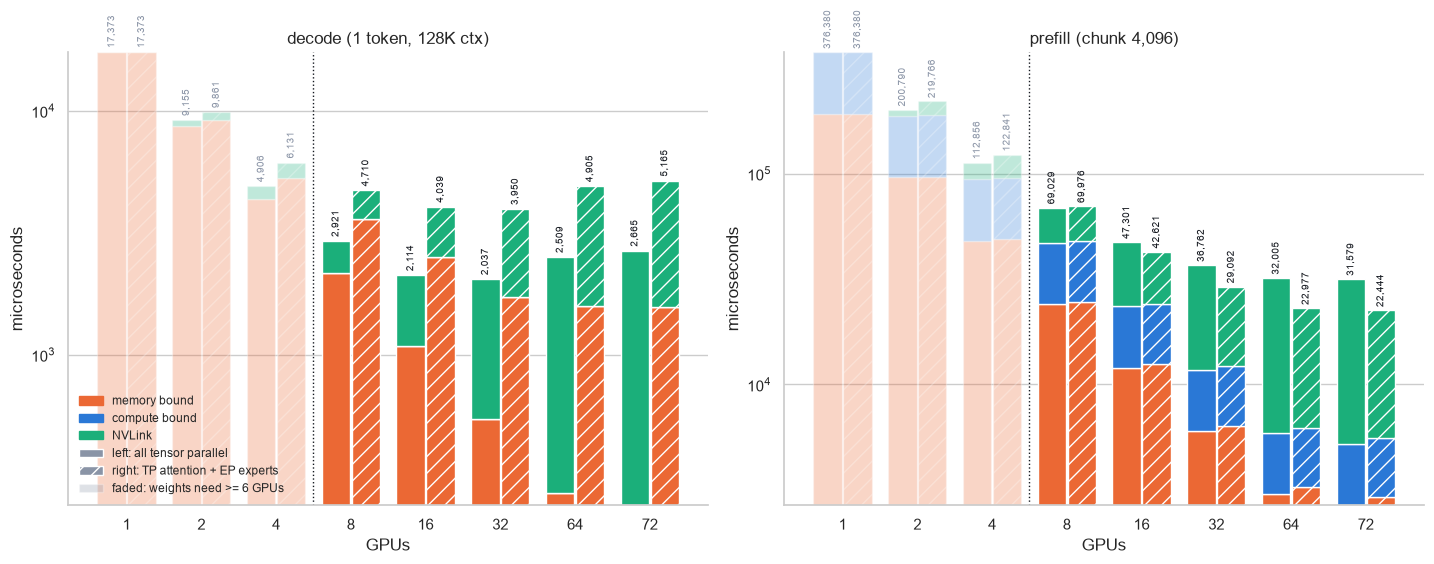

In [13]:
NVLINK = "#1baf7a"
need = int(np.ceil(weights_gb / (hw.hbm_bytes / 1e9)))
w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8))

for ax, tp, ep, label in (
    (axes[0], tp_dec, ep_dec, f"decode (1 token, {SEQ // 1024}K ctx)"),
    (axes[1], tp_pre, ep_pre, f"prefill (chunk {CHUNK:,})"),
):
    x = np.arange(len(GPUS))
    for off, frame, hatch in ((-w / 2 - 0.01, tp, ""), (w / 2 + 0.01, ep, "//")):
        for xi in range(len(GPUS)):
            r = frame.iloc[xi]
            a = 1.0 if r["fits"] else 0.28
            ax.bar(xi + off, r["memory us"], w, color=MEMORY, alpha=a, hatch=hatch, edgecolor="white")
            ax.bar(xi + off, r["compute us"], w, bottom=r["memory us"],
                   color=COMPUTE, alpha=a, hatch=hatch, edgecolor="white")
            ax.bar(xi + off, r["nvlink us"], w, bottom=r["memory us"] + r["compute us"],
                   color=NVLINK, alpha=a, hatch=hatch, edgecolor="white")
            ax.text(xi + off, r["total us"] * 1.06, f"{r['total us']:,.0f}", ha="center",
                    fontsize=7, color="#14181f" if r["fits"] else "#8a94a6", rotation=90)

    ax.axvline(np.argmax(tp["fits"].values) - 0.5, color="#14181f", lw=1, ls=":")
    ax.set_xticks(x, GPUS)
    ax.set_xlabel("GPUs")
    ax.set_ylabel("microseconds")
    ax.set_yscale("log")
    ax.set_title(label)
    ax.grid(axis="x", visible=False)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=MEMORY, label="memory bound"),
    plt.Rectangle((0, 0), 1, 1, color=COMPUTE, label="compute bound"),
    plt.Rectangle((0, 0), 1, 1, color=NVLINK, label="NVLink"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#8a94a6", label="left: all tensor parallel"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#8a94a6", hatch="//", edgecolor="white",
                  label="right: TP attention + EP experts"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#8a94a6", alpha=0.28,
                  label=f"faded: weights need >= {need} GPUs"),
]
axes[0].legend(handles=handles, frameon=False, fontsize=8.5, loc="lower left")
sns.despine()
plt.tight_layout()

### EP loses at decode and wins at prefill

**Decode: expert parallelism is worse.** At 8 GPUs, 4,932 us against all-TP's
3,107. Two independent reasons, both structural:

- **Load imbalance.** Only 16 experts are ever selected, so at 8 GPUs the busiest
  holds ~5 of them rather than the balanced 2 — a 2.5x tax on the MoE term. Past
  16 GPUs it is worse: the busiest GPU still holds 1-3 experts while most sit
  idle, so adding GPUs stops helping at all.
- **More collectives.** EP needs 2 all-to-alls per MoE layer where TP needed 1
  all-reduce, so 184 + 93 = 277 collectives against 186. At a 14 KB payload every
  one of those is pure latency, and latency does not shard.

**Prefill: expert parallelism wins, increasingly.** 20,228 us against 30,091 at
72 GPUs. Both reasons reverse:

- 65,536 assignments balance almost perfectly — the busiest GPU is within 10% of
  the mean even at 72 GPUs.
- The all-to-all payload **shrinks as `1/n`** (each GPU dispatches only its own
  tokens' latents), while TP's all-reduce payload is fixed at `batch x 7168`. They
  cross around 8 GPUs and diverge after.

Which is the concrete argument for **prefill/decode disaggregation**: the two
phases want different parallelism, and running one strategy for both means losing
on one of them.

---

# Appendix

Everything below supports the two tables above; none of it is needed to read them.

## A. Why so many intensities are exactly 1.00

Not a coincidence in the data — it is structural. Take any weight matmul at
batch 1 with bf16 weights:

$$I = \frac{\text{FLOPs}}{\text{bytes}} = \frac{2 \cdot |W|}{2\,\text{B} \cdot |W|} = 1$$

The `|W|` cancels, so the layer's shape is irrelevant. What is left is two 2s
that have **nothing to do with each other**:

- the numerator's 2 is *one multiply + one add* per parameter (rule 1)
- the denominator's 2 is *bytes per bf16 number*

They are unrelated quantities that happen to share a value. So the general rule
is

$$I \;=\; \frac{2 \cdot \text{batch}}{\text{bytes per weight}}$$

which explains the whole intensity column at a glance:

| | bytes/param | intensity at batch 1 |
|---|---|---|
| bf16 | 2.0 | **1.00** |
| fp8 | 1.0 | 2.00 |
| mxfp4 | 0.53125 | **3.76** ← this is `moe.experts` |

Two ways an op departs from it:

- **slightly below 1** (`kda.beta` at 0.990, `moe.router` at 0.999) — a small
  `d_out` means activation traffic is no longer negligible next to the weights,
  and it lands in the denominator only.
- **far above 1** (`mla.attn` at 53.3, `kda.recurrence` at 1.5) — no weights at
  all, so the rule does not apply. These read state or cache and reuse it, which
  is the only way to actually climb the roofline.

### The arithmetic behind one op

`kda.qkv_proj` — the largest single line item in the step. The 96 heads are in
here, but not where you might expect.

In [14]:
_ = explain_gemm(
    "kda.qkv_proj",
    d_in=cfg.d_model,
    d_out=cfg.kda_heads * cfg.kda_head_dim,
    layers=69,
    n_weights=3,
    heads=(cfg.kda_heads, cfg.kda_head_dim),
)

kda.qkv_proj   (69 layers, batch 1, bf16)
  d_out  = 96 heads x 128 = 12288   <- heads are folded into one width, not a repeated matmul
  params/layer  3 x 7168 x 12288 = 264,241,152

  FLOPs   69 x 2 x 1 x 264,241,152
          = 36,465,278,976 = 36.47 GFLOP
            the 2 is one multiply + one add per parameter

  weights 69 x 264,241,152 x 2.0 B = 36.47 GB
  activs  69 x 1 x (7168 + 3x12288) x 2 B = 0.0061 GB
          = 36.47 GB total

  intensity = 36.47 / 36.47 = 0.99983 FLOP/byte
  ideal (weights only) = 2 x 1 / 2.0 = 1.000


**Where the 96 heads went.** They are folded into the output width —
`96 x 128 = 12288` — and that is the *only* place they appear. There is no
separate multiply-by-96 anywhere in the FLOP count.

That is because multi-head attention does not run 96 matmuls. It runs **one**
`7168 x 12288` matmul and then *views* the result as 96 slices of 128. Heads are
a reshape, not a repeat. Multiplying by 96 again would overcount by 96x.

The other factors, each appearing exactly once:

| factor | value | why |
|---|---|---|
| `n_weights` | 3 | separate q, k, v projections (often fused into one kernel) |
| `2` | 2 | multiply + add per parameter |
| `batch` | 1 | one token in flight |
| `layers` | 69 | KDA layers in the stack |

And the byte side is the same parameter count times 2 bytes, which is precisely
why the intensity comes out at 1.00 — the weights dominate so completely that
the 6 MB of activations only drags it to 0.99983.

In [15]:
# same treatment for the two ops that break the pattern
print(">>> moe.experts -- MXFP4 weights lift intensity above 1\n")
_ = explain_gemm("moe.experts (16 live)", cfg.d_latent_moe, cfg.d_ff_expert,
                 layers=92, prec="mxfp4", n_weights=3 * cfg.n_active_routed)

print("\n" + "=" * 70)
print(">>> mla.attn -- no weights at all, so the rule does not apply\n")
row = ops.loc["mla.attn (vs cache)"]
cache_v = cfg.kv_lora_rank + cfg.qk_rope_head_dim
print(f"  reads   24 layers x {SEQ:,} tokens x {cache_v} values x 2 B = {row.bytes / 1e9:.2f} GB")
print(f"  does    24 x 2 x {SEQ:,} x {cfg.n_heads} heads x ({cfg.qk_head_dim} + {cfg.v_head_dim})")
print(f"          = {row.flops / 1e9:.2f} GFLOP")
print(f"  intensity {row.intensity:.1f}  <- HERE the 96 heads DO multiply:")
print("            each cached vector is read once and used by all 96 heads.")
print("            reuse is the only thing that moves you right on the roofline.")

>>> moe.experts -- MXFP4 weights lift intensity above 1

moe.experts (16 live)   (92 layers, batch 1, mxfp4)
  params/layer  48 x 3584 x 3072 = 528,482,304

  FLOPs   92 x 2 x 1 x 528,482,304
          = 97,240,743,936 = 97.24 GFLOP
            the 2 is one multiply + one add per parameter

  weights 92 x 528,482,304 x 0.53125 B = 25.83 GB
  activs  92 x 1 x (3584 + 48x3072) x 2 B = 0.0278 GB
          = 25.86 GB total

  intensity = 97.24 / 25.86 = 3.76066 FLOP/byte
  ideal (weights only) = 2 x 1 / 0.53125 = 3.765

>>> mla.attn -- no weights at all, so the rule does not apply

  reads   24 layers x 131,072 tokens x 576 values x 2 B = 3.62 GB
  does    24 x 2 x 131,072 x 96 heads x (192 + 128)
          = 193.27 GFLOP
  intensity 53.3  <- HERE the 96 heads DO multiply:
            each cached vector is read once and used by all 96 heads.
            reuse is the only thing that moves you right on the roofline.


## B. Machine intensity and the roofline

Ops have an arithmetic intensity; so does the machine. The GPU's is just

$$I_{\text{machine}} = \frac{\text{peak FLOP/s}}{\text{bandwidth}} \qquad [\text{FLOP}/\text{byte}]$$

— how much arithmetic it can do per byte it can fetch. This is the **ridge
point**: an op must supply at least this much work per byte to keep the tensor
cores fed. Supply less and the answer is bandwidth, whatever you do to the math.

Note the ridge *rises* as precision drops. Faster arithmetic over the same 8 TB/s
means you need more work per byte to saturate it, so quantising makes the
compute-bound target **harder** to hit, not easier.

In [16]:
print(machine_intensity(hw).round(1).to_string())
print(f"\nK3 whole step: {ops.flops.sum() / ops.bytes.sum():.2f} FLOP/byte")

       peak (PFLOP/s)  bandwidth (TB/s)  machine intensity (FLOP/byte)
bf16              2.5               8.0                          312.5
fp8               5.0               8.0                          625.0
mxfp4            15.0               8.0                         1875.0

K3 whole step: 2.88 FLOP/byte


In [17]:
vs_ridge(ops, hw).round(3)

,group,precision,op intensity,GB300 intensity,ratio,shortfall
op,,,,,,
kda.qkv_proj,KDA,bf16,1.000,312.5,0.003,313x under
moe.experts,MoE,mxfp4,3.762,1875.0,0.002,498x under
moe.shared,MoE,bf16,1.000,312.5,0.003,313x under
kda.gate,KDA,bf16,1.000,312.5,0.003,313x under
kda.out,KDA,bf16,1.000,312.5,0.003,313x under
moe.w_up,MoE,bf16,1.000,312.5,0.003,313x under
moe.w_down,MoE,bf16,1.000,312.5,0.003,313x under
mla.out,MLA,bf16,1.000,312.5,0.003,313x under
mla.gate,MLA,bf16,1.000,312.5,0.003,313x under


### The roofline

Attainable performance is `min(peak, bandwidth x intensity)` — a slanted
bandwidth roof that meets a flat compute roof at the ridge. Each op is plotted
where its intensity puts it.

Every op lands **on the diagonal**, far left of every ridge. That is what
"memory bound" looks like: performance is set entirely by how fast bytes arrive,
and the flat roofs overhead are unreachable.

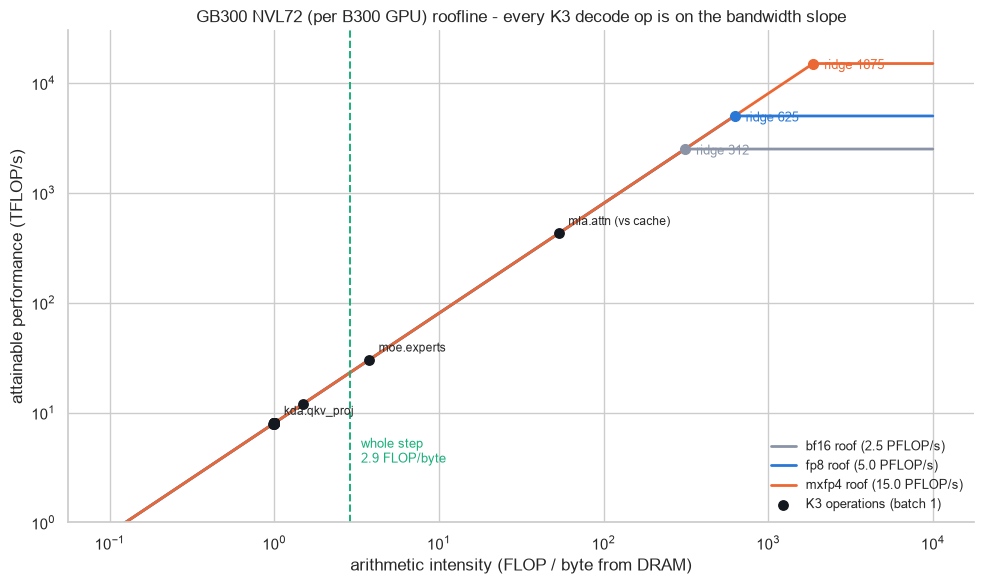

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
I = np.logspace(-1, 4, 300)

roofs = {"bf16": "#8a94a6", "fp8": COMPUTE, "mxfp4": MEMORY}
for prec, color in roofs.items():
    peak = hw.peak[prec]
    ax.plot(I, np.minimum(peak, hw.bandwidth * I) / 1e12, color=color, lw=2,
            label=f"{prec} roof ({peak / 1e15:.1f} PFLOP/s)")
    ridge = hw.balance[prec]
    ax.plot(ridge, peak / 1e12, "o", color=color, ms=7, zorder=5)
    ax.annotate(f"ridge {ridge:.0f}", (ridge, peak / 1e12), fontsize=9, color=color,
                textcoords="offset points", xytext=(8, -4))

achieved = ops.flops / ops.t
ax.scatter(ops.intensity, achieved / 1e12, s=46, color="#14181f", zorder=6,
           label="K3 operations (batch 1)")
for name in ["kda.qkv_proj", "moe.experts", "mla.attn (vs cache)"]:
    r = ops.loc[name]
    ax.annotate(name, (r.intensity, r.flops / r.t / 1e12), fontsize=8.5,
                textcoords="offset points", xytext=(7, 6))

whole = ops.flops.sum() / ops.bytes.sum()
ax.axvline(whole, color="#1baf7a", ls="--", lw=1.4)
ax.annotate(f"whole step\n{whole:.1f} FLOP/byte", (whole, 3.5), fontsize=9,
            color="#1baf7a", textcoords="offset points", xytext=(8, 0))

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("arithmetic intensity (FLOP / byte from DRAM)")
ax.set_ylabel("attainable performance (TFLOP/s)")
ax.set_title(f"{hw.name} roofline - every K3 decode op is on the bandwidth slope")
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.set_ylim(1, 3e4)
sns.despine()
plt.tight_layout()

## C. What sequence length changes in decode

The table is **decode**: one new token per step, attending over `seq` already in
the cache. So it is worth being precise about where `seq` enters, because it is
one row out of nineteen.

Every GEMM is independent of context. `kda.qkv_proj` reads the same 36.47 GB of
weights whether the cache holds 8K tokens or 1M — weights are weights. The same
goes for the experts, the shared experts, the router and the head.

`kda.recurrence` is flat too, but for a different reason: its state is a fixed
`96 x 128 x 128` per layer by construction, not by circumstance.

That leaves exactly one op that grows: **`mla.attn`**, which re-reads the whole
KV cache every step.

In [19]:
a, b = build_ops(cfg, batch=1, seq=8192), build_ops(cfg, batch=1, seq=1_048_576)
delta = pd.DataFrame({"8K ctx (GB)": a.bytes / 1e9, "1M ctx (GB)": b.bytes / 1e9})
delta["grows with seq"] = (delta["8K ctx (GB)"] - delta["1M ctx (GB)"]).abs() > 1e-9
print(f"ops affected by context length: {list(delta[delta['grows with seq']].index)}\n")
delta.round(3)

ops affected by context length: ['mla.attn (vs cache)']



,8K ctx (GB),1M ctx (GB),grows with seq
op,,,
kda.alpha,0.128,0.128,False
kda.alpha_up,0.219,0.219,False
kda.beta,0.096,0.096,False
kda.gate,12.158,12.158,False
kda.out,12.158,12.158,False
kda.qkv_proj,36.471,36.471,False
kda.recurrence,0.434,0.434,False
lm_head,2.349,2.349,False
mla.attn (vs cache),0.226,28.991,True


In [20]:
rows = []
for s in [8192, 32_768, 131_072, 524_288, 1_048_576]:
    d = build_ops(cfg, batch=1, seq=s, hw=hw)
    att = d.loc["mla.attn (vs cache)"]
    rows.append({"context": s, "total GB": d.bytes.sum() / 1e9,
                 "mla.attn GB": att.bytes / 1e9,
                 "attn share": att.bytes / d.bytes.sum(),
                 "ms/step": d.t.sum() * 1e3})

ctx_scan = pd.DataFrame(rows).set_index("context")
ctx_scan["attn share"] = ctx_scan["attn share"].map("{:.1%}".format)
ctx_scan.round(2)

,total GB,mla.attn GB,attn share,ms/step
context,,,,
8192,135.59,0.23,0.2%,16.95
32768,136.27,0.91,0.7%,17.03
131072,138.99,3.62,2.6%,17.37
524288,149.86,14.50,9.7%,18.73
1048576,164.35,28.99,17.6%,20.54


**So context is nearly free in decode, right up until it isn't.**

At 8K the cache read is 0.2% of the bytes moved — completely invisible next to
streaming weights. At 128K it is 2.6%. Only at 1M does it reach 17.6% and add
about 3 ms to the step.

This is the flip side of the earlier FLOP analysis, and the two are easy to
confuse. Measured in **FLOPs**, attention dominates at long context — 1,546 of
1,754 GFLOP at 1M. Measured in **bytes**, it is a minority of the traffic even
there. Since the step is memory bound, bytes are what set the wall clock, so the
FLOP-side story overstates how much long context costs during decode.

And this is with MLA compressing the cache 53x and only 24 of 93 layers keeping
one at all. Without those two things the same column would read ~6 TB at 1M
(§2), and context would be the only thing that mattered.

## D. Batch scaling in decode

Arithmetic intensity of the whole step is ~3 FLOP/byte. The GB300 can sustain
~312 FLOP/byte in bf16. Off by a factor of ~100, so the tensor cores idle while
HBM streams weights.

That is not a K3 problem, it is what batch-1 decode *is*: every weight is read to
produce a single token. The fix is batching — read the weight once, use it for
`B` tokens — which multiplies FLOPs by `B` while bytes stay flat.

Except MoE breaks that, which is the interesting part.

In [21]:
from roofline import experts_touched

rows = []
for b in [1, 4, 16, 64, 256, 1024]:
    o = build_ops(cfg, batch=b, seq=SEQ, hw=hw)
    t = o[["flops", "bytes", "t_compute", "t_memory"]].sum()
    rows.append({
        "batch": b,
        "experts woken": experts_touched(cfg.n_routed, cfg.n_active_routed, b),
        "TFLOP": t.flops / 1e12,
        "GB moved": t.bytes / 1e9,
        "intensity": t.flops / t.bytes,
        "ms/step": max(t.t_compute, t.t_memory) * 1e3,
        "tok/s": b / max(t.t_compute, t.t_memory),
    })

scale = pd.DataFrame(rows).set_index("batch")
scale.round(2)

,experts woken,TFLOP,GB moved,intensity,ms/step,tok/s
batch,,,,,,
1,16.00,0.40,138.99,2.88,17.37,57.56
4,62.31,1.60,226.06,7.08,28.26,141.56
16,224.41,6.40,537.03,11.92,67.13,238.35
64,613.20,25.61,1361.75,18.81,170.22,375.99
256,887.11,102.46,2592.31,39.52,324.04,790.03
1024,896.00,409.82,5760.16,71.15,720.02,1422.18


**Read the `experts woken` column against `GB moved`.**

A dense model batches for free: the weights are the same bytes no matter how many
tokens you push through, so intensity rises linearly with batch and you walk up
to the compute roof.

K3 does not get that. At batch 1 you read 16 experts per layer. By batch 256 the
batch collectively selects nearly all 896, so you are streaming the entire expert
bank to serve one step — the bytes grow almost as fast as the FLOPs and intensity
stalls. This is the central problem in MoE serving, and it is why expert
parallelism and routing locality get as much engineering attention as the kernels
do.

## E. Chunk size in prefill

In [22]:
rows = []
for ch in [512, 1024, 2048, 4096, 8192, 16384]:
    p = build_ops_prefill(cfg, chunk=ch, prior=0, hw=hw)
    rows.append({"chunk": ch,
                 "experts woken": experts_touched(cfg.n_routed, cfg.n_active_routed, ch),
                 "TFLOP": p.flops.sum() / 1e12,
                 "GB moved": p.bytes.sum() / 1e9,
                 "intensity": p.flops.sum() / p.bytes.sum(),
                 "ms": p.t.sum() * 1e3,
                 "tokens/s": ch / p.t.sum()})

sweep = pd.DataFrame(rows).set_index("chunk")
print(f"bf16 ridge {hw.balance['bf16']:.0f} FLOP/byte -- above it the chunk is compute bound\n")
sweep.round(1)

bf16 ridge 312 FLOP/byte -- above it the chunk is compute bound



,experts woken,TFLOP,GB moved,intensity,ms,tokens/s
chunk,,,,,,
512,895.9,106.1,1581.3,67.1,204.8,2500.2
1024,896.0,212.7,1607.0,132.3,228.8,4475.2
2048,896.0,426.9,1658.0,257.5,277.4,7383.3
4096,896.0,860.0,1760.1,488.6,376.4,10882.6
8192,896.0,1744.8,1964.3,888.3,581.8,14080.6
16384,896.0,3588.5,2372.6,1512.5,1022.3,16026.5


**Chunk size is the tuning knob, and the returns bend early.**

Bytes are nearly fixed — the whole expert bank gets read once no matter how small
the chunk — so doubling `C` almost doubles throughput at first. But every chunk
above ~1024 tokens already wakes all 896 experts, so past that you are only
amortising a cost that has stopped growing, and the curve flattens against the
compute roof instead.

That is the real reason engines chunk prefill in the low thousands: small enough
to bound activation memory, large enough that the unavoidable full sweep of the
expert bank is spread over enough tokens to stop mattering.

## F. Decode, per layer

The same table divided through by the layer count, so each row is what **one**
layer of that type does. This is the unit you reason about when you are looking
at a kernel trace.

In [23]:
op_table(ops, hw, per_layer=True).round(3)

,group,layers,GFLOP,GB from DRAM,intensity (FLOP/byte),COMPUTE bf16 (us),COMPUTE fp8 (us),COMPUTE mxfp4 (us),MEMORY (us),limited by
op,,,,,,,,,,
lm_head,Head,1,2.349,2.349,1.000,0.940,0.470,0.157,293.644,memory
kda.qkv_proj,KDA,69,0.528,0.529,1.000,0.211,0.106,0.035,66.071,memory
kda.gate,KDA,69,0.176,0.176,1.000,0.070,0.035,0.012,22.025,memory
kda.out,KDA,69,0.176,0.176,1.000,0.070,0.035,0.012,22.025,memory
kda.recurrence,KDA,69,0.009,0.006,1.500,0.004,0.002,0.001,0.786,memory
kda.alpha_up,KDA,69,0.003,0.003,0.992,0.001,0.001,0.000,0.396,memory
kda.alpha,KDA,69,0.002,0.002,0.992,0.001,0.000,0.000,0.231,memory
kda.beta,KDA,69,0.001,0.001,0.990,0.001,0.000,0.000,0.174,memory
mla.out,MLA,24,0.176,0.176,1.000,0.070,0.035,0.012,22.025,memory


## G. Decode runtime per layer

Per operation take `max(t_compute, t_memory)` — the resource that op waits on —
then sum those within a layer.

Caveat worth stating: this assumes ops run back to back and each saturates one
resource alone. Real kernels fuse and overlap, so read this as a floor on time,
not a prediction.

In [24]:
layers = by_layer(ops)
print(layers.round(2).to_string())
print()
print(summarise(ops, hw).round(3).to_string())

       instances  t_1layer_us  t_total_ms  compute-bound ops  memory-bound ops
group                                                                         
KDA         69.0       111.71        7.71                0.0               7.0
MoE         92.0        82.61        7.60                0.0               5.0
MLA         24.0        73.80        1.77                0.0               6.0
Head         1.0       293.64        0.29                0.0               1.0
MODEL      186.0          NaN       17.37                0.0              19.0

TFLOP / token               0.400
GB moved / token          138.986
arithmetic intensity        2.880
machine balance (bf16)    312.500
t_compute (ms)              0.128
t_memory (ms)              17.373
t_total (ms)               17.373
tokens/s (1 GPU)           57.560


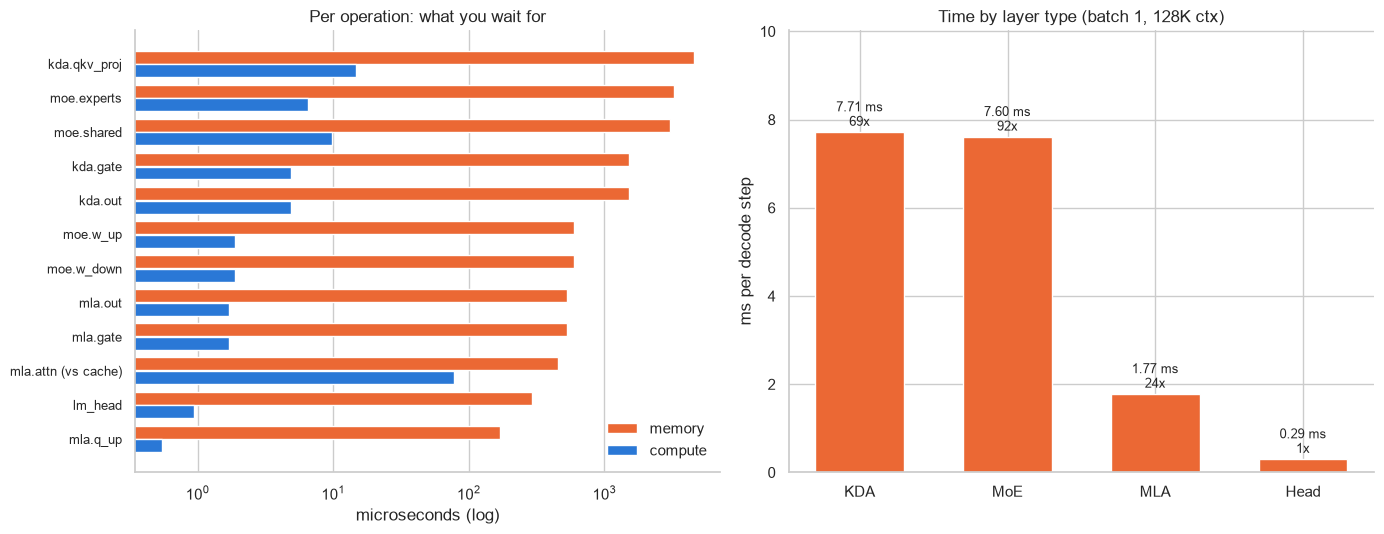

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

top = ops.head(12).iloc[::-1]
y = np.arange(len(top))
ax1.barh(y + 0.2, top.t_memory * 1e6, 0.38, color=MEMORY, label="memory")
ax1.barh(y - 0.2, top.t_compute * 1e6, 0.38, color=COMPUTE, label="compute")
ax1.set_yticks(y, top.index, fontsize=9)
ax1.set_xscale("log")
ax1.set_xlabel("microseconds (log)")
ax1.set_title("Per operation: what you wait for")
ax1.legend(frameon=False, loc="lower right")
ax1.grid(axis="y", visible=False)

lay = layers.drop("MODEL")
ax2.bar(lay.index, lay.t_total_ms, color=[MEMORY] * len(lay), width=0.6)
for i, (n, r) in enumerate(lay.iterrows()):
    ax2.text(i, r.t_total_ms + 0.15, f"{r.t_total_ms:.2f} ms\n{int(r.instances)}x",
             ha="center", fontsize=9)
ax2.set_ylabel("ms per decode step")
ax2.set_title(f"Time by layer type (batch {BATCH}, {SEQ // 1024}K ctx)")
ax2.set_ylim(0, lay.t_total_ms.max() * 1.3)

sns.despine()
plt.tight_layout()

### Does more compute help? (decode)

Sum the columns. This is the whole answer to the roofline question.

In [26]:
tbl = op_table(ops, hw)
tot = tbl[["COMPUTE bf16 (us)", "COMPUTE fp8 (us)", "COMPUTE mxfp4 (us)", "MEMORY (us)"]].sum()

print(f"memory bound      {tot['MEMORY (us)'] / 1e3:8.2f} ms")
for p in ["bf16", "fp8", "mxfp4"]:
    c = tot[f"COMPUTE {p} (us)"]
    print(f"compute bound @ {p:<6}{c / 1e3:7.3f} ms   ({tot['MEMORY (us)'] / c:5.0f}x under the memory bound)")

print(f"\nwhole-step intensity  {ops.flops.sum() / ops.bytes.sum():.2f} FLOP/byte")
print(f"machine balance bf16  {hw.balance['bf16']:.0f} FLOP/byte")
print(f"\n{(tbl['limited by'] == 'memory').sum()} of {len(tbl)} operations are memory bound;"
      f" {(tbl['limited by'] == 'compute').sum()} are compute bound.")

memory bound         17.37 ms
compute bound @ bf16    0.160 ms   (  109x under the memory bound)
compute bound @ fp8     0.080 ms   (  217x under the memory bound)
compute bound @ mxfp4   0.027 ms   (  651x under the memory bound)

whole-step intensity  2.88 FLOP/byte
machine balance bf16  312 FLOP/byte

19 of 19 operations are memory bound; 0 are compute bound.


## H. Prefill, per chunk

Everything so far is decode: one token per step. Prefill is the other half of
serving and it lands on the **other side of the ridge**.

Real engines do not swallow a whole prompt at once — activation memory blows up —
so this models **chunked prefill**: one chunk of `C` tokens with `P` already
cached. Three things change:

| | decode | prefill chunk |
|---|---|---|
| tokens through each weight | 1 | `C` (4096 below) |
| attention | 1 query vs `s` keys | `C` queries, causal over `P + C` |
| experts woken per layer | 16 of 896 | **all 896** |

The first is the whole story. FLOPs scale with `C` while weight bytes do not, so
intensity scales with `C` too — `2·C / bytes_per_weight` from the earlier rule.
At `C = 4096` in bf16 that is ~4096 FLOP/byte, way past the 312 ridge.

The third is what stops it being a clean win.

In [27]:
print(f"prefill chunk of {CHUNK:,} tokens, {PRIOR:,} already cached")
print(f"experts woken: {experts_touched(cfg.n_routed, cfg.n_active_routed, CHUNK):.1f} of {cfg.n_routed}\n")
op_table(pre, hw).round(2)

prefill chunk of 4,096 tokens, 0 already cached
experts woken: 896.0 of 896



,group,GFLOP,GB from DRAM,intensity (FLOP/byte),COMPUTE bf16 (us),COMPUTE fp8 (us),COMPUTE mxfp4 (us),MEMORY (us),limited by
op,,,,,,,,,
lm_head,Head,9620.73,3.75,2565.73,3848.29,1924.15,641.38,468.71,compute
kda.qkv_proj,KDA,149361.78,61.35,2434.42,59744.71,29872.36,9957.45,7669.28,compute
kda.gate,KDA,49787.26,23.15,2150.40,19914.90,9957.45,3319.15,2894.07,compute
kda.out,KDA,49787.26,23.15,2150.40,19914.90,9957.45,3319.15,2894.07,compute
kda.recurrence,KDA,2667.17,7.38,361.41,1066.87,533.43,177.81,922.48,compute
kda.alpha_up,KDA,889.06,7.24,122.88,355.62,177.81,59.27,904.40,memory
kda.alpha,KDA,518.62,4.25,122.01,207.45,103.72,34.57,531.33,memory
kda.beta,KDA,388.96,4.20,92.59,155.59,77.79,25.93,525.12,memory
mla.out,MLA,17317.31,8.05,2150.40,6926.92,3463.46,1154.49,1006.63,compute


## I. Prefill, per layer

Same division: one KDA layer, one MLA layer, one MoE layer, for a single chunk of
`CHUNK` tokens.

Read the `limited by` column against the decode version in step 4. Almost every
row flips to compute bound, because the layer now does `CHUNK` tokens of work for
the same weight read. The one that does not flip is `moe.experts`, which still
has to pull every expert it owns.

In [28]:
op_table(pre, hw, per_layer=True).round(3)

,group,layers,GFLOP,GB from DRAM,intensity (FLOP/byte),COMPUTE bf16 (us),COMPUTE fp8 (us),COMPUTE mxfp4 (us),MEMORY (us),limited by
op,,,,,,,,,,
lm_head,Head,1,9620.727,3.750,2565.727,3848.291,1924.145,641.382,468.713,compute
kda.qkv_proj,KDA,69,2164.664,0.889,2434.415,865.865,432.933,144.311,111.149,compute
kda.gate,KDA,69,721.555,0.336,2150.400,288.622,144.311,48.104,41.943,compute
kda.out,KDA,69,721.555,0.336,2150.400,288.622,144.311,48.104,41.943,compute
kda.recurrence,KDA,69,38.655,0.107,361.412,15.462,7.731,2.577,13.369,compute
kda.alpha_up,KDA,69,12.885,0.105,122.880,5.154,2.577,0.859,13.107,memory
kda.alpha,KDA,69,7.516,0.062,122.009,3.006,1.503,0.501,7.700,memory
kda.beta,KDA,69,5.637,0.061,92.590,2.255,1.127,0.376,7.610,memory
mla.out,MLA,24,721.555,0.336,2150.400,288.622,144.311,48.104,41.943,compute


## J. Prefill runtime per layer

Per operation take `max(t_compute, t_memory)`, sum within the layer.

In [29]:
pl = by_layer(pre)
print(f"chunk of {CHUNK:,} tokens, {PRIOR:,} prior\n")
print(pl.round(2).to_string())
print(f"\nper token: {pl.loc['MODEL', 't_total_ms'] * 1e3 / CHUNK:.1f} us"
      f"   vs decode {by_layer(ops).loc['MODEL', 't_total_ms'] * 1e3:.0f} us")

chunk of 4,096 tokens, 0 prior

       instances  t_1layer_us  t_total_ms  compute-bound ops  memory-bound ops
group                                                                         
MoE         92.0      2692.49      247.71                4.0               1.0
KDA         69.0      1486.99      102.60                4.0               3.0
MLA         24.0       925.83       22.22                6.0               0.0
Head         1.0      3848.29        3.85                1.0               0.0
MODEL      186.0          NaN      376.38               15.0               4.0

per token: 91.9 us   vs decode 17373 us


## K. Decode vs prefill

Same model, same GPU, opposite sides of the ridge.

In [30]:
dec = build_ops(cfg, batch=1, seq=131_072, hw=hw)

cmp = pd.DataFrame({
    "decode (1 tok)": [dec.flops.sum() / 1e12, dec.bytes.sum() / 1e9,
                       dec.flops.sum() / dec.bytes.sum(), dec.t.sum() * 1e3,
                       (dec.bound == "compute").sum(), 1 / dec.t.sum()],
    f"prefill ({CHUNK} tok)": [pre.flops.sum() / 1e12, pre.bytes.sum() / 1e9,
                               pre.flops.sum() / pre.bytes.sum(), pre.t.sum() * 1e3,
                               (pre.bound == "compute").sum(), CHUNK / pre.t.sum()],
}, index=["TFLOP", "GB moved", "intensity (FLOP/byte)", "ms", "compute-bound ops", "tokens/s"])
print(f"bf16 ridge: {hw.balance['bf16']:.0f} FLOP/byte\n")
cmp.round(1)

bf16 ridge: 312 FLOP/byte



,decode (1 tok),prefill (4096 tok)
TFLOP,0.4,860.0
GB moved,139.0,1760.1
intensity (FLOP/byte),2.9,488.6
ms,17.4,376.4
compute-bound ops,0.0,15.0
tokens/s,57.6,10882.6


**Prefill is ~170x more efficient per token, and the reason is amortisation.**

The chunk reads roughly the same bytes a single decode step does, but does 4096
tokens of work with them. Intensity goes 2.9 → 489, which clears the bf16 ridge
of 312, and 14 of 19 operations flip to compute bound.

**What stays memory bound is the interesting part.** `moe.experts` reads
**1,524 GB** for one chunk — that is the entire expert bank, because 4096 tokens
routing independently wake all 896 experts in every layer. It alone is ~190 ms of
the ~376 ms chunk, and no amount of extra compute touches it.

So the MoE sparsity that makes decode cheap in FLOPs does nothing for prefill
traffic: you pay to stream the whole model either way, you just get 4096 tokens
out of it instead of 1.

One modelling note: `mla.attn` shows an absurd intensity because flash attention
keeps the `C x C` score block in SRAM, so its DRAM traffic is only the KV it
reads and writes. The quadratic work is real; the quadratic *traffic* is not.

## L. How the parallelism cost is computed

Every number in the prefill chart comes from three terms. Nothing here is
measured — it is arithmetic on shapes, and each step is checkable.

### L.1 What sharding does to compute and memory

Under tensor parallelism a weight `(d_in, d_out)` is split across `n` GPUs, so
each holds `1/n` of it. Both sides of the roofline shrink together:

$$t_{\text{compute}} = \frac{\text{FLOPs}/n}{\text{peak}} \qquad t_{\text{memory}} = \frac{\text{bytes}/n}{\text{bandwidth}}$$

Because **both** divide by `n`, arithmetic intensity is unchanged — sharding
cannot move an operation across the ridge, only slide it down the same roof.
That is why the `limited by` column never flips as GPU count rises.

### L.2 The collective

Sharding leaves each GPU holding a *partial sum* of the layer output, so they
must be added. Ring all-reduce passes data around the ring twice (reduce-scatter,
then all-gather), touching `(n-1)/n` of the payload each pass:

$$t_{\text{allreduce}}(S, n) = \underbrace{\ell}_{\text{fixed floor}} + \underbrace{\frac{2(n-1)}{n} \cdot \frac{S}{B}}_{\text{wire time}}$$

The `2(n-1)/n` factor rises from 1 at `n=2` toward 2 as `n` grows — more GPUs
means *more* bytes crossing the wire per GPU, not fewer. This term never shrinks,
which is the whole reason the bars stop falling.

In [31]:
from roofline import BYTES

S_pre = CHUNK * cfg.d_model * BYTES["bf16"]
S_dec = 1 * cfg.d_model * BYTES["bf16"]

parts = pd.DataFrame({
    "ring factor 2(n-1)/n": [2 * (n - 1) / n for n in GPUS],
    "decode: wire us": [2 * (n - 1) / n * S_dec / fab.bw_per_gpu * 1e6 for n in GPUS],
    "decode: floor us": [fab.latency_at(n) * 1e6 for n in GPUS],
    "prefill: wire us": [2 * (n - 1) / n * S_pre / fab.bw_per_gpu * 1e6 for n in GPUS],
    "prefill: floor us": [fab.latency_at(n) * 1e6 for n in GPUS],
}, index=pd.Index(GPUS, name="GPUs"))

print(f"ONE all-reduce. payload: decode {S_dec / 1e3:.1f} KB, prefill {S_pre / 1e6:.1f} MB")
print(f"bandwidth {fab.bw_per_gpu / 1e9:.0f} GB/s, stack={fab.stack!r}\n")
parts.round(3)

ONE all-reduce. payload: decode 14.3 KB, prefill 58.7 MB
bandwidth 900 GB/s, stack='modern'



,ring factor 2(n-1)/n,decode: wire us,decode: floor us,prefill: wire us,prefill: floor us
GPUs,,,,,
1,0.000,0.000,0.0,0.000,0.0
2,1.000,0.016,2.5,65.245,2.5
4,1.500,0.024,3.0,97.867,3.0
8,1.750,0.028,4.0,114.178,4.0
16,1.875,0.030,5.5,122.334,5.5
32,1.938,0.031,8.0,126.412,8.0
64,1.969,0.031,12.0,128.451,12.0
72,1.972,0.031,13.0,128.677,13.0


Read the `wire` columns against the `floor` columns. At decode the payload is
so small that the fixed floor is ~1000x the wire time — the collective is pure
latency. At prefill it is the reverse. **Same formula, opposite regime**, purely
because of `S`.

### L.3 How many collectives

Megatron sharding puts one all-reduce after the attention block and one after the
FFN, in every layer. Expert parallelism replaces the FFN's all-reduce with two
all-to-alls, dispatch and combine:

In [32]:
counts = pd.DataFrame({
    "attention all-reduce": [cfg.n_layers, cfg.n_layers],
    "FFN all-reduce": [cfg.n_layers, 0],
    "MoE all-to-all": [0, 2 * cfg.n_moe_layers],
    "total collectives": [2 * cfg.n_layers, cfg.n_layers + 2 * cfg.n_moe_layers],
}, index=["all-TP", "TP attn + EP experts"])
counts

,attention all-reduce,FFN all-reduce,MoE all-to-all,total collectives
all-TP,93,93,0,186
TP attn + EP experts,93,0,184,277


### L.4 Why the all-to-all payload shrinks but the all-reduce payload does not

This is the crux of the EP-vs-TP result, and it is one line of algebra.

**All-reduce** combines a tensor every GPU holds a copy of, so the payload is the
full activation regardless of `n`:

$$S_{\text{AR}} = \text{batch} \times d_{\text{model}} \times 2\,\text{B}$$

**All-to-all** ships each GPU's *own* tokens to the experts they chose. With the
batch spread across `n` GPUs, each sends only its `batch/n` share:

$$S_{\text{A2A}}(n) = \frac{\text{batch}}{n} \times k \times d_{\text{latent}} \times 2\,\text{B}$$

One is constant in `n`, the other falls as `1/n`. Setting them equal gives the
crossover exactly:

$$n^{*} = \frac{k \cdot d_{\text{latent}}}{d_{\text{model}}} = \frac{16 \times 3584}{7168} = 8$$

Below 8 GPUs TP ships less; above 8, EP does — which is precisely where the
hatched bars overtake the solid ones. The `d_latent = 3584` rather than `7168` is
worth a factor of 2 here: K3 dispatches the **compressed** latent, because
LatentMoE projects down before routing.

In [33]:
a2a = np.array([CHUNK / n * cfg.n_active_routed * cfg.d_latent_moe * 2 for n in GPUS])
ar = np.array([S_pre] * len(GPUS))

payload = pd.DataFrame({
    "all-reduce MB (TP)": ar / 1e6,
    "all-to-all MB (EP)": a2a / 1e6,
    "EP / TP": a2a / ar,
}, index=pd.Index(GPUS, name="GPUs"))
star = cfg.n_active_routed * cfg.d_latent_moe / cfg.d_model
print(f"crossover n* = k*d_latent/d_model = {cfg.n_active_routed}*{cfg.d_latent_moe}"
      f"/{cfg.d_model} = {star:.0f} GPUs\n")
payload.round(3)

crossover n* = k*d_latent/d_model = 16*3584/7168 = 8 GPUs



,all-reduce MB (TP),all-to-all MB (EP),EP / TP
GPUs,,,
1,58.72,469.762,8.000
2,58.72,234.881,4.000
4,58.72,117.441,2.000
8,58.72,58.720,1.000
16,58.72,29.360,0.500
32,58.72,14.680,0.250
64,58.72,7.340,0.125
72,58.72,6.524,0.111


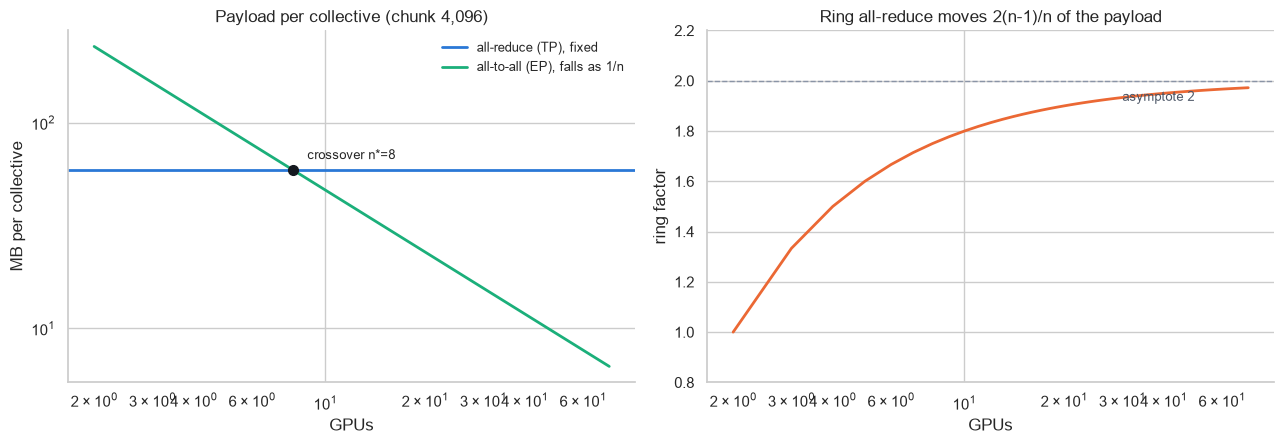

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
n_ = np.arange(2, 73)

ax1.axhline(S_pre / 1e6, color=COMPUTE, lw=2, label="all-reduce (TP), fixed")
ax1.plot(n_, CHUNK / n_ * cfg.n_active_routed * cfg.d_latent_moe * 2 / 1e6,
         color=NVLINK, lw=2, label="all-to-all (EP), falls as 1/n")
ax1.plot(star, S_pre / 1e6, "o", color="#14181f", ms=7, zorder=5)
ax1.annotate(f"crossover n*={star:.0f}", (star, S_pre / 1e6), fontsize=9,
             textcoords="offset points", xytext=(10, 8))
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel("GPUs"); ax1.set_ylabel("MB per collective")
ax1.set_title(f"Payload per collective (chunk {CHUNK:,})")
ax1.legend(frameon=False, fontsize=9)

ax2.plot(n_, [2 * (n - 1) / n for n in n_], color=MEMORY, lw=2)
ax2.axhline(2, color="#8a94a6", ls="--", lw=1)
ax2.annotate("asymptote 2", (30, 1.92), fontsize=9, color="#4a5464")
ax2.set_xscale("log")
ax2.set_xlabel("GPUs"); ax2.set_ylabel("ring factor")
ax2.set_title("Ring all-reduce moves 2(n-1)/n of the payload")
ax2.set_ylim(0.8, 2.2)

sns.despine()
plt.tight_layout()

### L.5 Load imbalance, the term only EP pays

TP is balanced by construction — every GPU gets an equal slice of every weight.
EP is not: `k x batch` token-expert assignments land in `n` bins at random, and
the step waits on the **fullest** bin, not the average.

`busiest_gpu_experts()` estimates it as balls-in-bins: the largest `t` for which
at least one bin is still expected to hold `t` or more. It is why EP is poor at
decode (16 assignments over 8 GPUs is deeply lumpy) and fine at prefill (65,536
assignments smooth out).

In [35]:
imb = pd.DataFrame({
    "decode: busiest": [busiest_gpu_experts(cfg.n_active_routed, 1, n) for n in GPUS],
    "decode: penalty": [expert_load_imbalance(cfg.n_active_routed, 1, n) for n in GPUS],
    "prefill: busiest": [busiest_gpu_experts(cfg.n_active_routed, CHUNK, n) for n in GPUS],
    "prefill: penalty": [expert_load_imbalance(cfg.n_active_routed, CHUNK, n) for n in GPUS],
}, index=pd.Index(GPUS, name="GPUs"))
print(f"decode: {cfg.n_active_routed} assignments    "
      f"prefill: {cfg.n_active_routed * CHUNK:,} assignments\n")
imb.round(2)

decode: 16 assignments    prefill: 65,536 assignments



,decode: busiest,decode: penalty,prefill: busiest,prefill: penalty
GPUs,,,,
1,16.0,1.00,65536.00,1.00
2,9.0,1.12,32981.13,1.01
4,6.0,1.50,16597.13,1.01
8,5.0,2.50,8376.58,1.02
16,4.0,4.00,4246.71,1.04
32,3.0,6.00,2167.15,1.06
64,3.0,12.00,1116.29,1.09
72,3.0,13.50,998.46,1.10


### L.6 Putting it together

$$t_{\text{step}}(n) \;=\; \underbrace{\sum_{\text{ops}} \frac{\max(t_{\text{compute}},\, t_{\text{memory}})}{n}}_{\text{shards; } \times\text{ imbalance for EP}} \;+\; \underbrace{N_{\text{coll}} \cdot t_{\text{collective}}(S, n)}_{\text{does not shard}}$$

Three assumptions worth naming, all of them optimistic:

1. **Compute, memory and communication are serialised.** Real engines overlap
   collectives with compute — the single biggest thing this model misses.
2. **Perfect strong scaling of the sharded part.** No kernel-efficiency loss from
   smaller per-GPU tiles, which is exactly where TP hurts and EP does not.
3. **A latency floor read off a small measured table** and interpolated between
   points, with no modelling of NVLink SHARP / multicast (worth ~5% at 8 GPUs,
   ~13-36% at 64) — see L.7.

So read the curves as an upper bound on how well parallelism can go, and the
crossover as the structural result — the shapes hold even where the absolute
numbers do not.

### L.7 Where the latency floor comes from

This is the number the whole communication term rests on, so it is worth being
explicit that it is **measured, not derived** — and that it is not one number.

Two findings changed how it is modelled here:

**It scales with participant count.** NCCL's own analytic cost model
(`src/graph/tuning.cc`) makes the structure plain: single-node NVLink all-reduce
costs `baseLat + 2(N-1) x hwLat`, with `baseLat = 6.6 us` and `hwLat = 0.6 us`
for the low-latency protocol. That predicts 15.0 us at 8 GPUs against a measured
15.7 (8x H100, NCCL 2.20), and 10.2 at 4 GPUs against a measured 11.0 (GB200).
A constant floor was simply wrong.

**It moved ~8x in mid-2025.** NCCL 2.27 shipped symmetric-memory kernels that cut
small-message all-reduce on a 32-rank GB200 domain from ~47 us to ~6 us. So the
same hardware has two very different answers depending on the software stack,
and most published benchmarks are still in the slow regime.

`Fabric(stack="modern")` assumes NCCL >= 2.27 symmetric kernels, CUDA Graphs, one
process per GPU. `stack="legacy"` is everything else. CUDA Graphs are not
optional for the modern numbers: a kernel launch alone is ~4.5 us, more than the
entire graphed collective on 8 Blackwell GPUs.

Two things deliberately **not** modelled: NVLink SHARP / multicast turns `2N-2`
ring steps into 2 regardless of `N` (~5% at 8 GPUs, ~13-36% at 64), and the
speed-of-light floor on Blackwell NVLink is ~1.4 us, which nothing can beat.

In [36]:
lat = pd.DataFrame({
    "modern us": [Fabric(stack="modern").latency_at(n) * 1e6 for n in GPUS],
    "legacy us": [Fabric(stack="legacy").latency_at(n) * 1e6 for n in GPUS],
}, index=pd.Index(GPUS, name="GPUs"))
lat["legacy / modern"] = lat["legacy us"] / lat["modern us"].replace(0, np.nan)
print("small-message all-reduce floor, measured\n")
lat.round(1)

small-message all-reduce floor, measured



,modern us,legacy us,legacy / modern
GPUs,,,
1,0.0,0.0,NaN
2,2.5,7.8,3.1
4,3.0,11.0,3.7
8,4.0,16.0,4.0
16,5.5,30.0,5.5
32,8.0,60.0,7.5
64,12.0,120.0,10.0
72,13.0,135.0,10.4


In [37]:
# how much the stack assumption is worth, end to end
stacks = {}
for st in ["modern", "legacy"]:
    f = Fabric(stack=st)
    stacks[f"{st}: all-TP"] = tensor_parallel(pre, cfg, GPUS, CHUNK, hw, f, weights_gb)["total us"]
    stacks[f"{st}: TP+EP"] = hybrid_parallel(pre, cfg, GPUS, CHUNK, hw, f, weights_gb)["total us"]

print(f"prefill chunk {CHUNK:,}, total us per chunk\n")
pd.DataFrame(stacks).round(0)

prefill chunk 4,096, total us per chunk



,modern: all-TP,modern: TP+EP,legacy: all-TP,legacy: TP+EP
GPUs,,,,
1,376380.0,376380.0,376380.0,376380.0
2,200790.0,219766.0,201776.0,221234.0
4,112856.0,122841.0,114344.0,125057.0
8,69029.0,69976.0,71261.0,73300.0
16,47301.0,42621.0,51858.0,49408.0
32,36762.0,29092.0,46434.0,43496.0
64,32005.0,22977.0,52093.0,52893.0
72,31579.0,22444.0,54271.0,56238.0


## M. Can the NVLink cost be avoided?

Three different answers, and only one of them actually removes bytes from the
wire. Worth separating, because they fail in different places.

### M.1 Hide it — overlap communication with compute

The model sums the three terms, which assumes they run back to back. Real engines
issue a collective and keep computing, so the honest lower bound is
`max(shard, comm)` rather than `shard + comm`.

This is the single biggest thing the model overstates.

### M.0 The three tricks, drawn

**Trick 1 — OVERLAP.** Same bytes, moved at the same time as the compute rather
than after it.

```
serialised  (what the model computes)

  GPU  ├── compute 5,561 ──┤├────── NVLink 16,883 ──────┤     = 22,444 us


overlapped  (what an engine actually does)

  compute  ├── 5,561 ──┤
  NVLink   ├──────────── 16,883 ────────────┤                 = 16,883 us
           └─ hidden ──┘└────── still exposed ─────┘

  the collective is longer than the compute, so only part of it hides.
  max(shard, comm) -- never better than the larger of the two.
```

**Trick 2 — CUT A DIFFERENT WAY.** Tensor parallel slices *inside* each layer, so
every layer needs a collective. Pipeline slices *between* layers, so only the
seams do.

```
TENSOR PARALLEL          cut vertically, through every layer
                         every cut edge needs an all-reduce

   layer  1   │ GPU0 │ GPU1 │ GPU2 │ GPU3 │  ══► all-reduce
   layer  2   │ GPU0 │ GPU1 │ GPU2 │ GPU3 │  ══► all-reduce
   layer  3   │ GPU0 │ GPU1 │ GPU2 │ GPU3 │  ══► all-reduce
    ...       │  ..  │  ..  │  ..  │  ..  │       ...
   layer 93   │ GPU0 │ GPU1 │ GPU2 │ GPU3 │  ══► all-reduce
              └──────┴──────┴──────┴──────┘
                                              186 collectives / step
                                              22,231 us


PIPELINE PARALLEL        cut horizontally, between layers
                         only the seams need a message

   GPU0   layers  1..23  ────┐
                             ├─► handoff  (point-to-point, 68 us)
   GPU1   layers 24..46  ────┤
                             ├─► handoff
   GPU2   layers 47..69  ────┤
                             ├─► handoff
   GPU3   layers 70..93  ────┘
                                              3 handoffs / microbatch
                                              474 us at 8 stages
```

Same GPUs, same fabric, **47x less traffic** — purely from where the knife goes.
The bill arrives elsewhere: stages idle while the pipe fills and drains, and a
token now makes `P-1` serial hops, so per-token latency rises.

**And the MoE variant of the same idea** — slice the expert bank by *owner*
instead of by *matrix row*:

```
TP on experts            every GPU holds a slice of every expert

   expert   1  │g0│g1│g2│g3│
   expert   2  │g0│g1│g2│g3│      all GPUs touch all 16 live experts
     ...                          ══► all-reduce, payload fixed at
   expert 896  │g0│g1│g2│g3│          batch x 7168


EP on experts            each GPU owns whole experts, tokens travel

   GPU0  experts   1..224  ─┐
   GPU1  experts 225..448  ─┤  ══► all-to-all: dispatch the 3584-d latent
   GPU2  experts 449..672  ─┤      to the owner, combine results back
   GPU3  experts 673..896  ─┘      payload falls as batch/n
```

**Trick 3 — AMORTISE.** The collective floor is charged per *step*, not per token.
Put more tokens in the step.

```
batch 1      ┌───┐
             │tok│ ───────── 186 collectives ─────────►   1,113 us / token
             └───┘

batch 256    ┌───┬───┬───┬─── ... ───┬───┐
             │tok│tok│tok│           │tok│ ── 186 ──►         9.5 us / token
             └───┴───┴───┴─── ... ───┴───┘
             └────────── 256 tokens ─────────┘
                                                   the same 186 collectives,
                                                   split 256 ways
```

Payload grows from 14 KB to 3.6 MB, which is still nowhere near bandwidth-bound —
so almost the whole 117x is free. Speculative decoding does the same thing along
the other axis: verify `k` tokens per forward pass, divide the floor by `k`.

In [38]:
shard_dec = ep_dec["memory us"] + ep_dec["compute us"]
shard_pre = ep_pre["memory us"] + ep_pre["compute us"]

overlap = pd.DataFrame({
    "decode serial": ep_dec["total us"],
    "decode overlapped": np.maximum(shard_dec, ep_dec["nvlink us"]),
    "prefill serial": ep_pre["total us"],
    "prefill overlapped": np.maximum(shard_pre, ep_pre["nvlink us"]),
})
overlap["decode saved"] = (1 - overlap["decode overlapped"] / overlap["decode serial"]).map("{:.0%}".format)
overlap["prefill saved"] = (1 - overlap["prefill overlapped"] / overlap["prefill serial"]).map("{:.0%}".format)
print("TP attention + EP experts, perfect overlap vs serialised\n")
overlap.round(0)

TP attention + EP experts, perfect overlap vs serialised



,decode serial,decode overlapped,prefill serial,prefill overlapped,decode saved,prefill saved
GPUs,,,,,,
1,17373.0,17373.0,376380.0,376380.0,0%,0%
2,9861.0,9162.0,219766.0,188995.0,7%,14%
4,6131.0,5293.0,122841.0,94901.0,14%,23%
8,4710.0,3597.0,69976.0,47745.0,24%,32%
16,4039.0,2511.0,42621.0,24093.0,38%,43%
32,3950.0,2220.0,29092.0,16880.0,44%,42%
64,4905.0,3327.0,22977.0,16747.0,32%,27%
72,5165.0,3604.0,22444.0,16883.0,30%,25%


Perfect overlap is worth 20-40%, and **it caps out**. Once communication
exceeds the compute you could hide it behind, `max()` stops helping — at 72 GPUs
the shard work is 5,561 us against 16,883 us of communication, so two thirds of
the collective time is exposed no matter how well you pipeline it.

Overlap buys you a constant factor. It does not change the shape.

### M.2 Move it — change which axis you shard

This is the one that actually removes bytes. Tensor parallelism communicates
**twice per layer** because it splits matrices *within* a layer. Pipeline
parallelism splits *between* layers, so it communicates only at stage boundaries
— a point-to-point handoff of one activation, `P-1` times for `P` stages, instead
of 186 collectives.

In [39]:
S = CHUNK * cfg.d_model * BYTES["bf16"]
hop = fab.latency_at(2) + S / fab.bw_per_gpu   # point-to-point, not a collective

pipe = pd.DataFrame({
    "stages": [2, 4, 8, 16],
    "handoffs": [P - 1 for P in [2, 4, 8, 16]],
    "comm us": [(P - 1) * hop * 1e6 for P in [2, 4, 8, 16]],
    "GB/stage": [weights_gb / P for P in [2, 4, 8, 16]],
}).set_index("stages")
pipe["fits/stage"] = pipe["GB/stage"] <= hw.hbm_bytes / 1e9

print(f"one handoff: {S / 1e6:.1f} MB point-to-point = {hop * 1e6:.0f} us")
print(f"TP+EP at 8 GPUs, same chunk: {ep_pre.loc[8, 'nvlink us']:,.0f} us "
      f"across {cfg.n_layers + 2 * cfg.n_moe_layers} collectives\n")
pipe.round(1)

one handoff: 58.7 MB point-to-point = 68 us
TP+EP at 8 GPUs, same chunk: 22,231 us across 277 collectives



,handoffs,comm us,GB/stage,fits/stage
stages,,,,
2,1,67.7,780.0,False
4,3,203.2,390.0,False
8,7,474.2,195.0,True
16,15,1016.2,97.5,True


**474 us against 22,231 us** — a 47x reduction in communication, for the same
chunk on the same fabric. Nothing clever happened: pipeline parallelism simply
communicates 7 times instead of 277.

The catch is what pipelining costs elsewhere:

- **Bubbles.** Stages idle while the pipeline fills and drains. Amortised away by
  many microbatches in prefill; painful in decode, where one token must traverse
  every stage in sequence.
- **Latency, not throughput.** A token's journey now includes `P-1` serial
  handoffs, so per-token latency rises even as throughput improves.
- **Weights must still fit per stage** — the `fits/stage` column.

Which is why production stacks nest them: **TP inside a node** where NVLink is
fast, **PP across nodes** where it is not, and **EP for the experts**. Each axis
is applied where its communication is cheapest.

### M.3 Amortise it — spread the floor over more tokens

For decode specifically, the collective cost is *per step*, not per token. So
anything that produces more tokens per step divides the floor:

- **Larger batch.** 186 collectives whether you decode 1 token or 256. The payload
  grows, but at 14 KB there is enormous headroom before bandwidth matters.
- **Speculative decoding / MTP.** Verify `k` tokens in one forward pass and the
  per-token collective cost drops by `k`. K3's released config has
  `num_nextn_predict_layers: 0`, so this would need a draft model.

None of these avoid the bytes. They just stop paying the floor so often.

In [40]:
rows = []
for b in [1, 8, 64, 256]:
    o = build_ops(cfg, batch=b, seq=SEQ, hw=hw)
    t = hybrid_parallel(o, cfg, [8, 32], b, hw, fab, weights_gb)
    for n in [8, 32]:
        rows.append({"batch": b, "GPUs": n,
                     "comm us/step": t.loc[n, "nvlink us"],
                     "comm us/token": t.loc[n, "nvlink us"] / b,
                     "total us/token": t.loc[n, "total us"] / b})

amort = pd.DataFrame(rows).set_index(["GPUs", "batch"]).sort_index()
print("decode: the collective floor is per STEP, so batching divides it\n")
amort.round(2)

decode: the collective floor is per STEP, so batching divides it



comm us/step  comm us/token  total us/token
GPUs batch                                             
8    1           1113.16        1113.16         4709.91
     8           1149.26         143.66          968.03
     64          1438.05          22.47          400.11
     256         2428.19           9.49          175.82
32   1           2219.58        2219.58         3950.08
     8           2244.64         280.58          584.66
     64          2445.12          38.21          150.49
     256         3132.48          12.24           57.03

### M.4 Summary

| approach | what it does | ceiling |
|---|---|---|
| **overlap** | hides comm behind compute | 20-40%, then `max()` binds |
| **pipeline instead of TP** | 7 handoffs instead of 277 collectives | bubbles, per-token latency |
| **batch / speculate** | amortises a per-step floor | decode only; memory for KV |
| **EP instead of TP for experts** | all-to-all payload falls as `1/n` | load imbalance at small batch |

The honest answer to "can it be avoided": **the bytes cannot, but almost nothing
forces you to pay them on the critical path.** The 186-collectives-per-step figure
in the main chart is what you get from the simplest possible sharding, and every
technique above is a way of not doing that.